# Bike Share Demand Prediction

## Project Overview
This project aims to predict hourly bike rental demand using the Bike Sharing Dataset.  
The workflow includes data cleaning, exploratory data analysis, feature engineering, regression modeling, and evaluation.

## Why this project matters
Accurate bike demand prediction can help bike-sharing companies:
- optimize bike availability
- improve operational efficiency
- reduce shortages and overstock
- better understand usage patterns across time and weather conditions

## Problem Statement
Bike-sharing systems generate large amounts of real-time usage data.  
The goal of this project is to build a regression model that predicts the number of bike rentals (`cnt`) for each hour based on time, season, weather, and historical demand patterns.

## Target Variable
- `cnt`: total number of bike rentals

## Machine Learning Task
- Supervised Learning
- Regression Problem

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import warnings

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
plt.style.use("default")

In [57]:
bikes=pd.read_csv("hour.csv")

## Dataset Description
The dataset used in this project is the **Bike Sharing Dataset**, specifically the hourly data file (`hour.csv`).

### Important features
- `season`: season of the year
- `yr`: year indicator
- `mnth`: month
- `hr`: hour of the day
- `holiday`: whether the day is a holiday
- `weekday`: day of the week
- `workingday`: whether the day is a working day
- `weathersit`: weather situation
- `temp`: normalized temperature
- `atemp`: normalized feeling temperature
- `hum`: humidity
- `windspeed`: wind speed
- `cnt`: total bike rentals

In [58]:
bikes

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0000,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0000,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0000,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0000,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17374,17375,2012-12-31,1,1,12,19,0,1,1,2,0.26,0.2576,0.60,0.1642,11,108,119
17375,17376,2012-12-31,1,1,12,20,0,1,1,2,0.26,0.2576,0.60,0.1642,8,81,89
17376,17377,2012-12-31,1,1,12,21,0,1,1,1,0.26,0.2576,0.60,0.1642,7,83,90
17377,17378,2012-12-31,1,1,12,22,0,1,1,1,0.26,0.2727,0.56,0.1343,13,48,61


In [59]:
print("Shape of dataset:", bikes.shape)
print("\nColumn names:")
print(bikes.columns.tolist())

Shape of dataset: (17379, 17)

Column names:
['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']


## Initial Data Inspection
We first examine:
- dataset shape
- column names
- data types
- missing values
- duplicate rows

In [60]:
bikes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [61]:
bikes.describe().T

,count,mean,std,min,25%,50%,75%,max
instant,17379.0,8690.000000,5017.029500,1.00,4345.5000,8690.0000,13034.5000,17379.0000
season,17379.0,2.501640,1.106918,1.00,2.0000,3.0000,3.0000,4.0000
yr,17379.0,0.502561,0.500008,0.00,0.0000,1.0000,1.0000,1.0000
mnth,17379.0,6.537775,3.438776,1.00,4.0000,7.0000,10.0000,12.0000
hr,17379.0,11.546752,6.914405,0.00,6.0000,12.0000,18.0000,23.0000
holiday,17379.0,0.028770,0.167165,0.00,0.0000,0.0000,0.0000,1.0000
weekday,17379.0,3.003683,2.005771,0.00,1.0000,3.0000,5.0000,6.0000
workingday,17379.0,0.682721,0.465431,0.00,0.0000,1.0000,1.0000,1.0000
weathersit,17379.0,1.425283,0.639357,1.00,1.0000,1.0000,2.0000,4.0000
temp,17379.0,0.496987,0.192556,0.02,0.3400,0.5000,0.6600,1.0000


In [62]:
bikes.isnull().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [63]:
print("Duplicate rows:", bikes.duplicated().sum())

Duplicate rows: 0


## Data Quality Notes
At this stage, we verify whether the dataset contains:
- missing values
- duplicated observations
- incorrect data types
- irrelevant columns

## Data Cleaning
We create a working copy of the dataset and remove columns that are not needed for modeling.

### Removed columns
- `instant`: row index, not useful for prediction
- `dteday`: raw date column, because time-related features already exist separately
- `casual` and `registered`: these directly contribute to the target `cnt`, so keeping them would cause data leakage

In [64]:
bikes_pre=bikes.copy()

In [65]:
bikes_pre=bikes_pre.drop(["instant"],axis=1)

In [66]:
bikes_pre=bikes_pre.drop(["dteday","casual","registered"],axis=1)

In [67]:
print("Shape after dropping unnecessary columns:", bikes_pre.shape)
bikes_pre.info()

Shape after dropping unnecessary columns: (17379, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   season      17379 non-null  int64  
 1   yr          17379 non-null  int64  
 2   mnth        17379 non-null  int64  
 3   hr          17379 non-null  int64  
 4   holiday     17379 non-null  int64  
 5   weekday     17379 non-null  int64  
 6   workingday  17379 non-null  int64  
 7   weathersit  17379 non-null  int64  
 8   temp        17379 non-null  float64
 9   atemp       17379 non-null  float64
 10  hum         17379 non-null  float64
 11  windspeed   17379 non-null  float64
 12  cnt         17379 non-null  int64  
dtypes: float64(4), int64(9)
memory usage: 1.7 MB


## Exploratory Data Analysis (EDA)
In this section, we explore the relationships between bike demand and different numerical and categorical features.
The goal is to identify patterns, trends, seasonality, and potential feature importance.

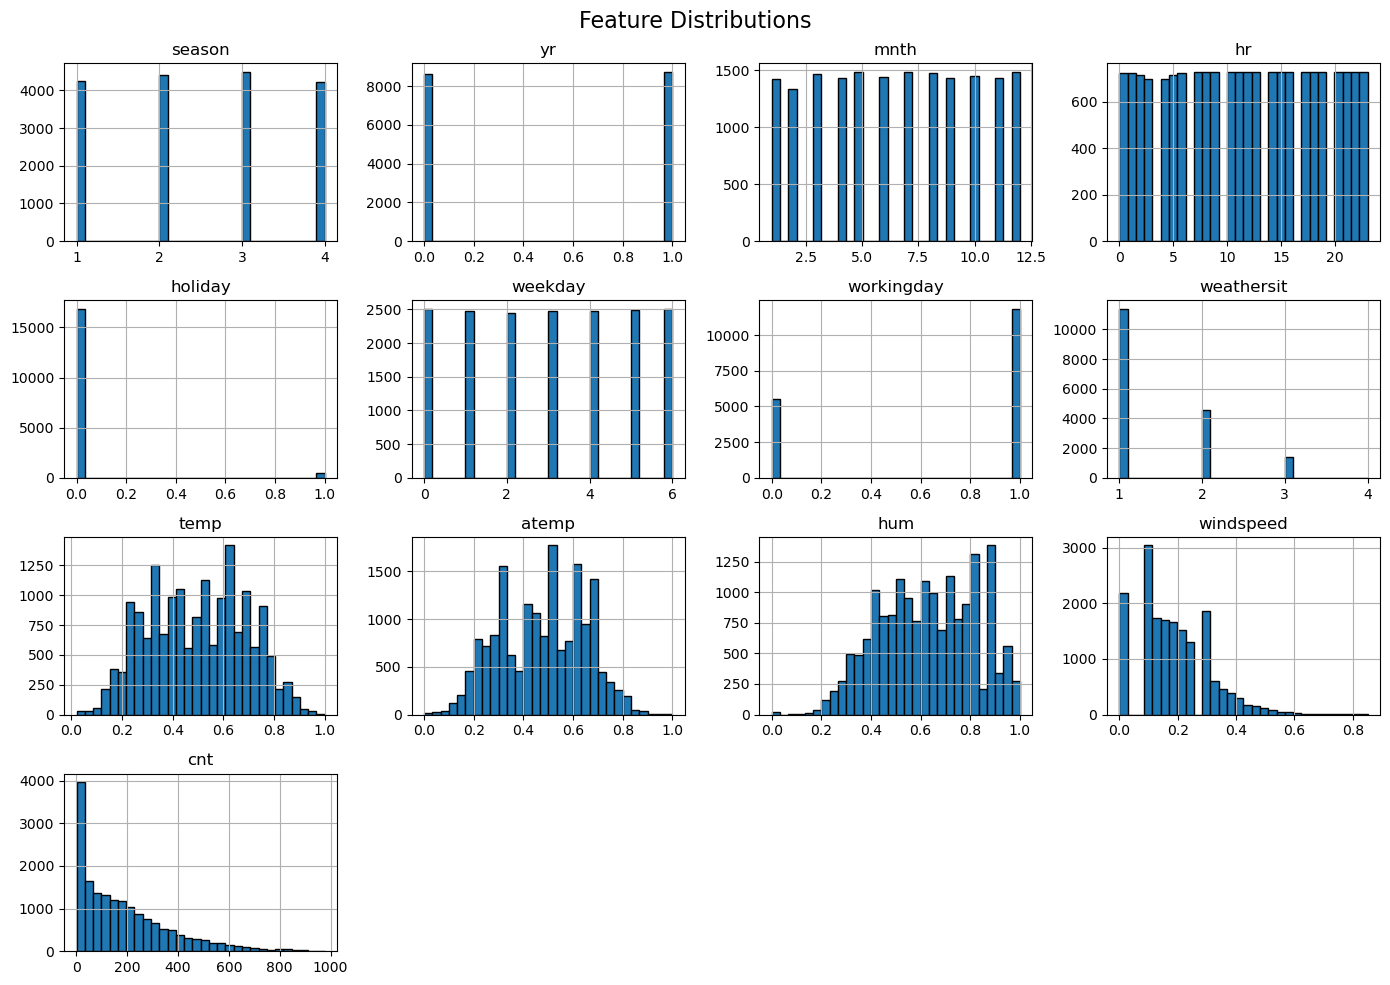

In [68]:
bikes_pre.hist(figsize=(14, 10), bins=30, edgecolor="black")
plt.suptitle("Feature Distributions", fontsize=16)
plt.tight_layout()
plt.show()

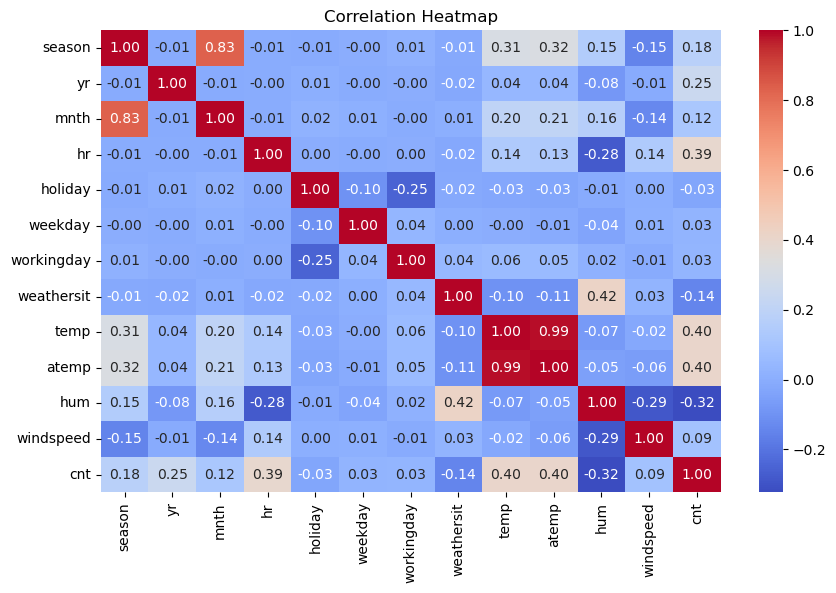

In [69]:
plt.figure(figsize=(10, 6))
sns.heatmap(bikes_pre.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

## Relationship Between Numerical Features and Demand
We visualize how continuous variables such as temperature, humidity, and windspeed relate to bike rental demand.

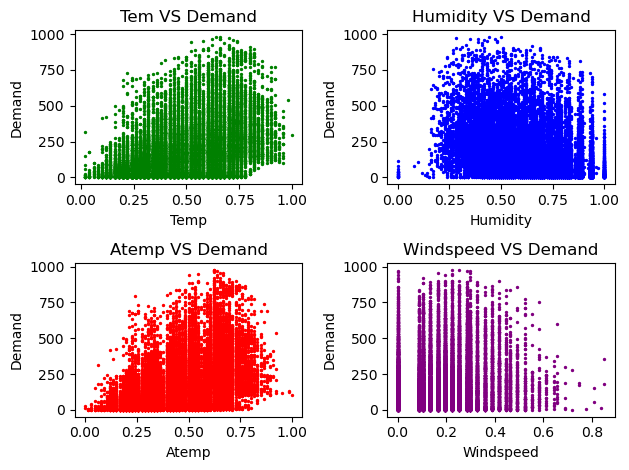

In [70]:
plt.subplot(2,2,1)
plt.title("Tem VS Demand")
plt.scatter(bikes_pre['temp'],bikes_pre['cnt'],s=2,c='g')
plt.xlabel("Temp")
plt.ylabel("Demand")
#hum
plt.subplot(2,2,2)
plt.title("Humidity VS Demand")
plt.scatter(bikes_pre['hum'], bikes_pre['cnt'], s=2, c='b')
plt.xlabel("Humidity")
plt.ylabel("Demand")
#atemp
plt.subplot(2,2,3)
plt.title("Atemp VS Demand")
plt.scatter(bikes_pre['atemp'], bikes_pre['cnt'], s=2, c='r')
plt.xlabel("Atemp")
plt.ylabel("Demand")
#windspeed
plt.subplot(2,2,4)
plt.title("Windspeed VS Demand")
plt.scatter(bikes_pre['windspeed'], bikes_pre['cnt'], s=2, c='purple')
plt.xlabel("Windspeed")
plt.ylabel("Demand")

plt.tight_layout()
plt.show()

## Average Demand Across Categorical Features
We examine how bike demand changes across:
- season
- year
- month
- holiday
- weekday
- working day
- weather situation
- hour of the day

<BarContainer object of 4 artists>

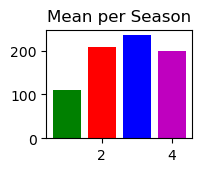

In [71]:
plt.subplot(3,3,1)
plt.title('Mean per Season')
colors=['g','r','b','m']
cat_list=bikes_pre['season'].unique()
cat_avg=bikes_pre.groupby('season').mean()['cnt']
plt.bar(cat_list,cat_avg,color=colors)

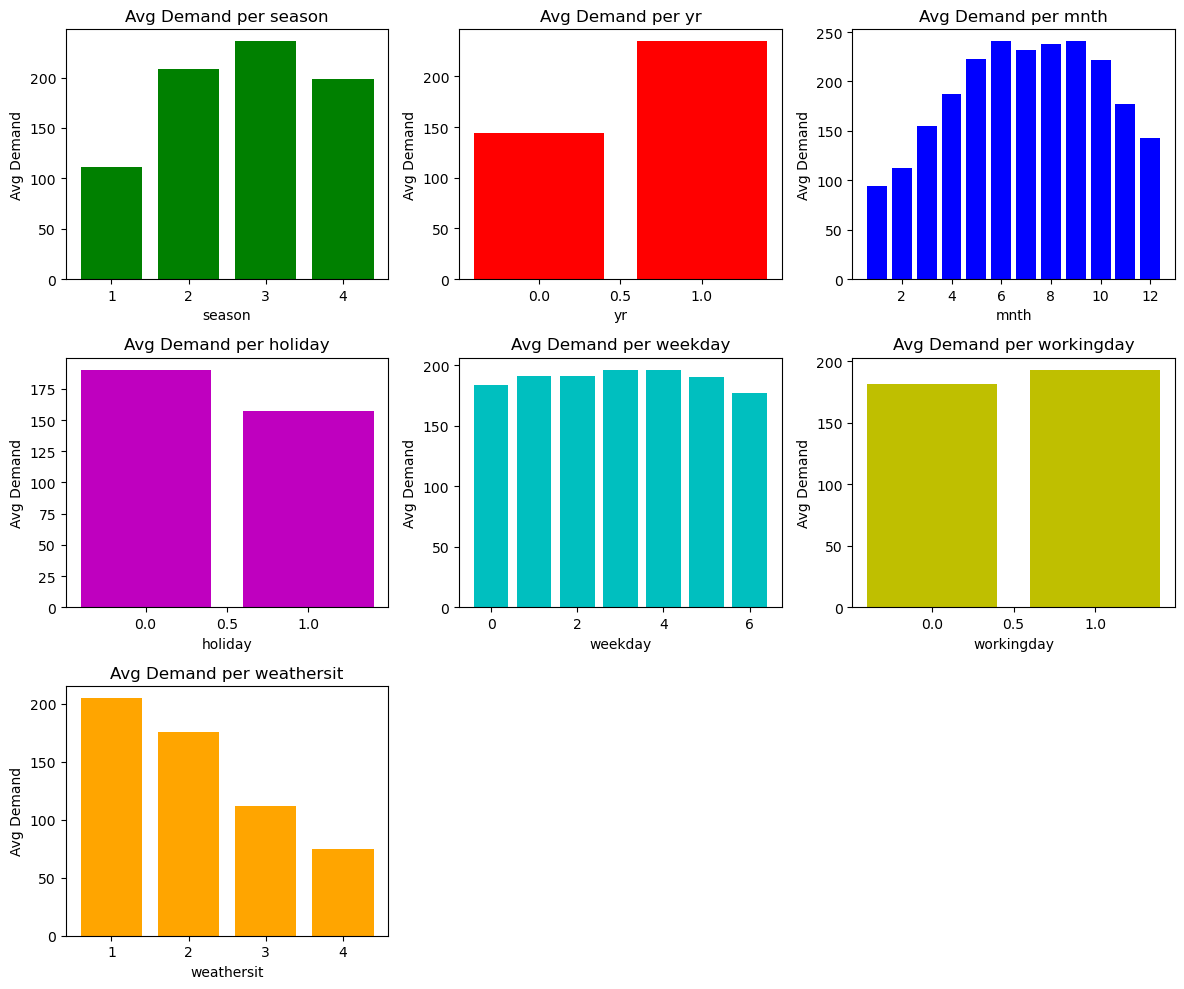

In [72]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))

cat_cols = ['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit']

colors = ['g','r','b','m','c','y','orange']

for i, col in enumerate(cat_cols):
    plt.subplot(3,3,i+1)
    
    cat_list = bikes_pre[col].unique()
    cat_avg = bikes_pre.groupby(col)['cnt'].mean()
    
    plt.bar(cat_list, cat_avg, color=colors[i % len(colors)])
    plt.title(f"Avg Demand per {col}")
    plt.xlabel(col)
    plt.ylabel("Avg Demand")

plt.tight_layout()
plt.show()

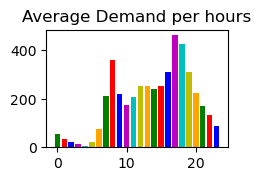

In [73]:
plt.subplot(3,3,1)
plt.title("Average Demand per hours")
cat_list=bikes_pre['hr'].unique()
cat_avg=bikes_pre.groupby('hr').mean()['cnt']
plt.bar(cat_list,cat_avg,color=colors)
plt.tight_layout()

## Key Insights from EDA
Some clear patterns can be observed from the analysis:

- Bike demand tends to vary significantly by hour of the day.
- Demand is affected by seasonal changes.
- Weather conditions influence rental activity.
- Temperature appears to have a positive relationship with bike demand.
- Humidity and windspeed may negatively affect demand in some cases.

These observations suggest that both time-based and weather-based variables are valuable predictors.

## Feature Engineering
Feature engineering is an important step in this project because bike rental demand is strongly influenced by time patterns and recent historical demand.

In this section, we:
- prepare the target variable
- create lag features
- encode categorical variables
- prepare the data for regression modeling

## Target Transformation
The target variable `cnt` is usually right-skewed because bike demand can vary widely across hours.

To reduce skewness and stabilize variance, we apply a logarithmic transformation to the target variable before training the model.

In [74]:
bikes_pre['cnt'].describe()

count    17379.000000
mean       189.463088
std        181.387599
min          1.000000
25%         40.000000
50%        142.000000
75%        281.000000
max        977.000000
Name: cnt, dtype: float64

In [75]:
bikes_pre['cnt'].quantile([0.25,0.5,0.75])

0.25     40.0
0.50    142.0
0.75    281.0
Name: cnt, dtype: float64

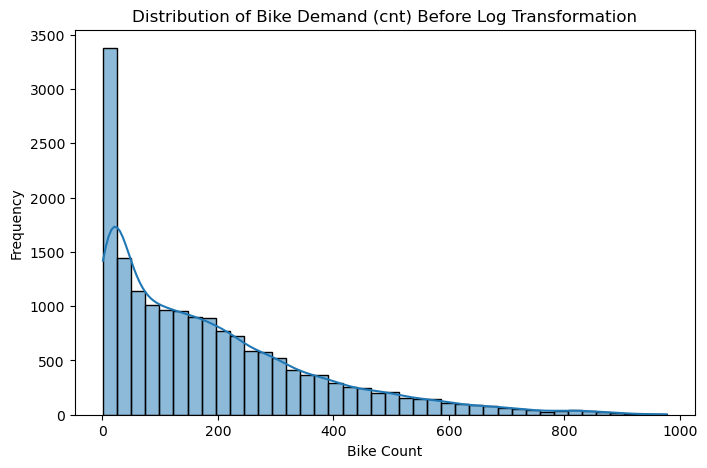

In [76]:
plt.figure(figsize=(8, 5))
sns.histplot(bikes_pre["cnt"], bins=40, kde=True)
plt.title("Distribution of Bike Demand (cnt) Before Log Transformation")
plt.xlabel("Bike Count")
plt.ylabel("Frequency")
plt.show()

In [77]:
bikes_pre["cnt"] = np.log1p(bikes_pre["cnt"])

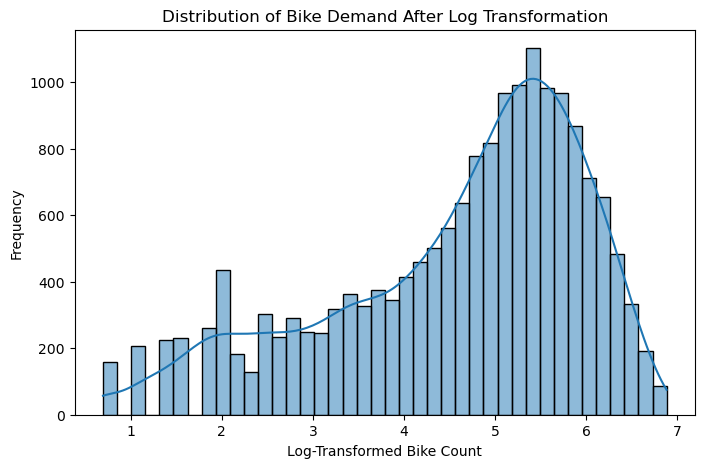

In [78]:
plt.figure(figsize=(8, 5))
sns.histplot(bikes_pre["cnt"], bins=40, kde=True)
plt.title("Distribution of Bike Demand After Log Transformation")
plt.xlabel("Log-Transformed Bike Count")
plt.ylabel("Frequency")
plt.show()

## Observation
After applying the log transformation, the target distribution becomes less skewed, which can help linear regression perform better.

## Lag Features
Bike demand is time-dependent, so recent demand values can be strong predictors of future demand.

To capture this pattern, we create lag features:
- `t_1`: previous hour demand
- `t_2`: demand two hours earlier
- `t_3`: demand three hours earlier

In [79]:
correlation=bikes_pre[['temp','atemp','hum','windspeed','cnt']].corr()

In [80]:
correlation

,temp,atemp,hum,windspeed,cnt
temp,1.000000,0.987672,-0.069881,-0.023125,0.388694
atemp,0.987672,1.000000,-0.051918,-0.062336,0.385523
hum,-0.069881,-0.051918,1.000000,-0.290105,-0.340790
windspeed,-0.023125,-0.062336,-0.290105,1.000000,0.115275
cnt,0.388694,0.385523,-0.340790,0.115275,1.000000


#drop irrelevant feature

In [81]:
bikes_pre=bikes_pre.drop(['weekday','yr','workingday','atemp','windspeed'], axis=1)

(array([-12, -11, -10,  -9,  -8,  -7,  -6,  -5,  -4,  -3,  -2,  -1,   0,
          1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12]),
 array([0.8904038 , 0.89060694, 0.8909857 , 0.8917795 , 0.89363605,
        0.89814323, 0.90600324, 0.91703343, 0.9321079 , 0.9515578 ,
        0.9728527 , 0.9908855 , 1.        , 0.9908855 , 0.9728527 ,
        0.9515578 , 0.9321079 , 0.91703343, 0.90600324, 0.89814323,
        0.89363605, 0.8917795 , 0.8909857 , 0.89060694, 0.8904038 ],
       dtype=float32),
 <matplotlib.lines.Line2D at 0x264d9594e30>)

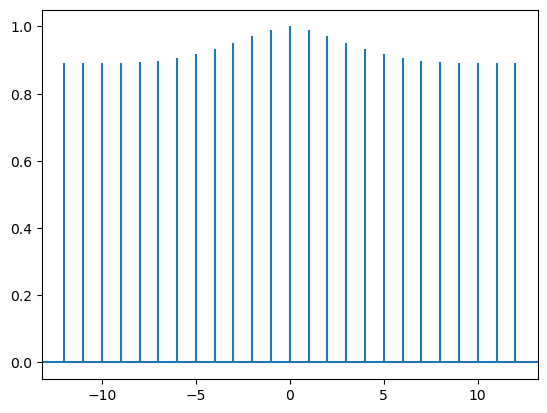

In [82]:
df=pd.to_numeric(bikes_pre['cnt'],downcast='float')
plt.acorr(df,maxlags=12)

In [83]:
t1=bikes_pre['cnt'].shift(+1).to_frame()
t1.columns=['t_1']
t2=bikes_pre['cnt'].shift(+2).to_frame()
t2.columns=['t_2']
t3=bikes_pre['cnt'].shift(+3).to_frame()
t3.columns=['t_3']
bikes_pre_lages=pd.concat([bikes_pre,t1,t2,t3],axis=1)

In [84]:
bikes_pre_lages

,season,mnth,hr,holiday,weathersit,temp,hum,cnt,t_1,t_2,t_3
0,1,1,0,0,1,0.24,0.81,2.833213,NaN,NaN,NaN
1,1,1,1,0,1,0.22,0.80,3.713572,2.833213,NaN,NaN
2,1,1,2,0,1,0.22,0.80,3.496508,3.713572,2.833213,NaN
3,1,1,3,0,1,0.24,0.75,2.639057,3.496508,3.713572,2.833213
4,1,1,4,0,1,0.24,0.75,0.693147,2.639057,3.496508,3.713572
...,...,...,...,...,...,...,...,...,...,...,...
17374,1,12,19,0,2,0.26,0.60,4.787492,4.812184,5.105945,5.370638
17375,1,12,20,0,2,0.26,0.60,4.499810,4.787492,4.812184,5.105945
17376,1,12,21,0,1,0.26,0.60,4.510860,4.499810,4.787492,4.812184
17377,1,12,22,0,1,0.26,0.56,4.127134,4.510860,4.499810,4.787492


## Why rows were dropped
Lag features create missing values in the first few rows because there is no historical data before the beginning of the dataset.
These rows are removed before model training.

In [85]:
bikes_pre_lages=bikes_pre_lages.dropna()

In [86]:
bikes_pre_lages

,season,mnth,hr,holiday,weathersit,temp,hum,cnt,t_1,t_2,t_3
3,1,1,3,0,1,0.24,0.75,2.639057,3.496508,3.713572,2.833213
4,1,1,4,0,1,0.24,0.75,0.693147,2.639057,3.496508,3.713572
5,1,1,5,0,2,0.24,0.75,0.693147,0.693147,2.639057,3.496508
6,1,1,6,0,1,0.22,0.80,1.098612,0.693147,0.693147,2.639057
7,1,1,7,0,1,0.20,0.86,1.386294,1.098612,0.693147,0.693147
...,...,...,...,...,...,...,...,...,...,...,...
17374,1,12,19,0,2,0.26,0.60,4.787492,4.812184,5.105945,5.370638
17375,1,12,20,0,2,0.26,0.60,4.499810,4.787492,4.812184,5.105945
17376,1,12,21,0,1,0.26,0.60,4.510860,4.499810,4.787492,4.812184
17377,1,12,22,0,1,0.26,0.56,4.127134,4.510860,4.499810,4.787492


In [87]:
bikes_pre_lages.dtypes

season          int64
mnth            int64
hr              int64
holiday         int64
weathersit      int64
temp          float64
hum           float64
cnt           float64
t_1           float64
t_2           float64
t_3           float64
dtype: object

## Encoding Categorical Variables
Some variables in the dataset are categorical, such as season and weather condition.
To use them in linear regression, we convert them into numerical dummy variables using one-hot encoding.

In [88]:
bikes_pre_lages['season']=bikes_pre_lages['season'].astype('category')
bikes_pre_lages['holiday']=bikes_pre_lages['holiday'].astype('category')
bikes_pre_lages['mnth']=bikes_pre_lages['mnth'].astype('category')
bikes_pre_lages['hr']=bikes_pre_lages['hr'].astype('category')

In [89]:
bikes_pre_lages=pd.get_dummies(bikes_pre_lages,drop_first=True)

In [90]:
bikes_pre_lages

,weathersit,temp,hum,cnt,t_1,t_2,t_3,season_2,season_3,season_4,mnth_2,mnth_3,mnth_4,mnth_5,mnth_6,mnth_7,mnth_8,mnth_9,mnth_10,mnth_11,mnth_12,hr_1,hr_2,hr_3,hr_4,hr_5,hr_6,hr_7,hr_8,hr_9,hr_10,hr_11,hr_12,hr_13,hr_14,hr_15,hr_16,hr_17,hr_18,hr_19,hr_20,hr_21,hr_22,hr_23,holiday_1
3,1,0.24,0.75,2.639057,3.496508,3.713572,2.833213,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,1,0.24,0.75,0.693147,2.639057,3.496508,3.713572,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
5,2,0.24,0.75,0.693147,0.693147,2.639057,3.496508,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
6,1,0.22,0.80,1.098612,0.693147,0.693147,2.639057,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
7,1,0.20,0.86,1.386294,1.098612,0.693147,0.693147,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17374,2,0.26,0.60,4.787492,4.812184,5.105945,5.370638,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False
17375,2,0.26,0.60,4.499810,4.787492,4.812184,5.105945,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
17376,1,0.26,0.60,4.510860,4.499810,4.787492,4.812184,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
17377,1,0.26,0.56,4.127134,4.510860,4.499810,4.787492,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False


In [91]:
bikes_pre_lages = bikes_pre_lages.replace({True: 1, False: 0})

In [92]:
bikes_pre_lages

,weathersit,temp,hum,cnt,t_1,t_2,t_3,season_2,season_3,season_4,mnth_2,mnth_3,mnth_4,mnth_5,mnth_6,mnth_7,mnth_8,mnth_9,mnth_10,mnth_11,mnth_12,hr_1,hr_2,hr_3,hr_4,hr_5,hr_6,hr_7,hr_8,hr_9,hr_10,hr_11,hr_12,hr_13,hr_14,hr_15,hr_16,hr_17,hr_18,hr_19,hr_20,hr_21,hr_22,hr_23,holiday_1
3,1,0.24,0.75,2.639057,3.496508,3.713572,2.833213,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,1,0.24,0.75,0.693147,2.639057,3.496508,3.713572,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5,2,0.24,0.75,0.693147,0.693147,2.639057,3.496508,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
6,1,0.22,0.80,1.098612,0.693147,0.693147,2.639057,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
7,1,0.20,0.86,1.386294,1.098612,0.693147,0.693147,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17374,2,0.26,0.60,4.787492,4.812184,5.105945,5.370638,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
17375,2,0.26,0.60,4.499810,4.787492,4.812184,5.105945,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
17376,1,0.26,0.60,4.510860,4.499810,4.787492,4.812184,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
17377,1,0.26,0.56,4.127134,4.510860,4.499810,4.787492,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0


In [93]:
y=bikes_pre_lages[['cnt']]
x=bikes_pre_lages.drop(['cnt'],axis=1)


In [94]:
tr_size=0.7*len(x)
tr_size=int(tr_size)

In [95]:
x_train=x.values[0:tr_size]
x_test=x.values[tr_size:len(x)]
y_train=y.values[0:tr_size]
y_test=y.values[tr_size:len(y)]

## Model Training
We train a Linear Regression model as a baseline regression approach.

Linear Regression is simple, interpretable, and useful as a first model for understanding how well the engineered features explain bike demand.

In [96]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
reg=LinearRegression()
reg.fit(x_train,y_train)
r_train=reg.score(x_train,y_train)
r_test=reg.score(x_test,y_test)
y_pred=reg.predict(x_test)
mse=math.sqrt(mean_squared_error(y_test,y_pred))

In [97]:
r_train

0.9293967457717154

In [98]:
r_test

0.9345785168910186

In [99]:
mse = mean_squared_error(y_test, y_pred)
rmse = math.sqrt(mse)

print("MSE:", mse)
print("RMSE:", rmse)

MSE: 0.12518453624726664
RMSE: 0.3538142680097379


In [102]:
y_test_actual = np.expm1(y_test)
y_pred_actual = np.expm1(y_pred)

rmse_actual = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))

print("RMSE (actual):", rmse_actual)

RMSE (actual): 75.47746442630067


In [103]:
y_pred

array([[3.36684519],
       [3.00817819],
       [3.17702126],
       ...,
       [4.30909537],
       [4.25010723],
       [3.68324581]])

In [101]:
mse

0.12518453624726664

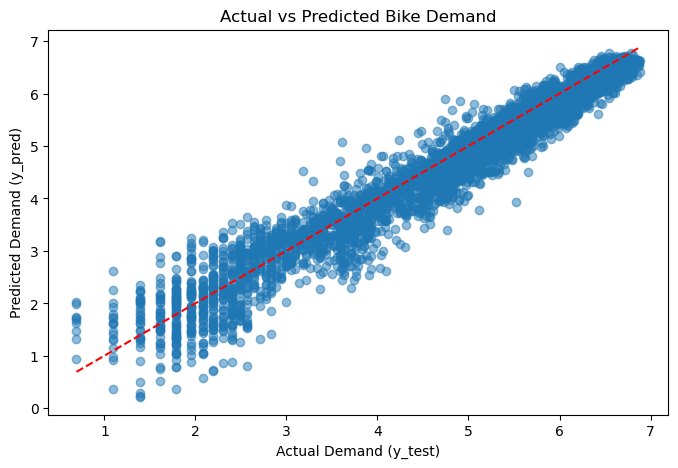

In [104]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Demand (y_test)")
plt.ylabel("Predicted Demand (y_pred)")
plt.title("Actual vs Predicted Bike Demand")


plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')

plt.show()

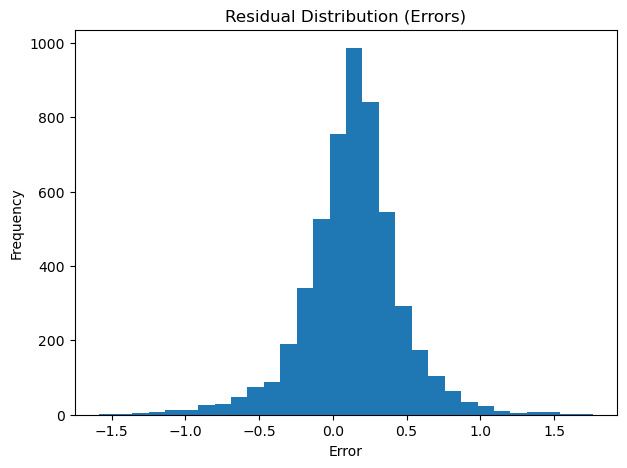

In [105]:
residuals = y_test - y_pred

plt.figure(figsize=(7,5))
plt.hist(residuals, bins=30)
plt.title("Residual Distribution (Errors)")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()

In [106]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.9345785168910186


## Saving the Model
The trained model is saved using joblib so it can be reused later for predictions without retraining.

In [107]:
import joblib

joblib.dump(reg, "bike_share_model.pkl")



['bike_share_model.pkl']

In [108]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(x_train, y_train)

rf_pred = rf.predict(x_test)

print("RF RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))

RF RMSE: 0.3176556858407328


In [109]:

actual = np.ravel(y_test)
predicted = np.ravel(y_pred)

print("Actual length:", len(actual))
print("Predicted length:", len(predicted))


min_len = min(len(actual), len(predicted))

comparison_df = pd.DataFrame({
    "Actual": actual[:min_len],
    "Predicted": predicted[:min_len]
})

comparison_df.head()

Actual length: 5213
Predicted length: 5213


,Actual,Predicted
0,3.610918,3.366845
1,2.484907,3.008178
2,2.079442,3.177021
3,3.135494,3.146235
4,3.970292,4.221332


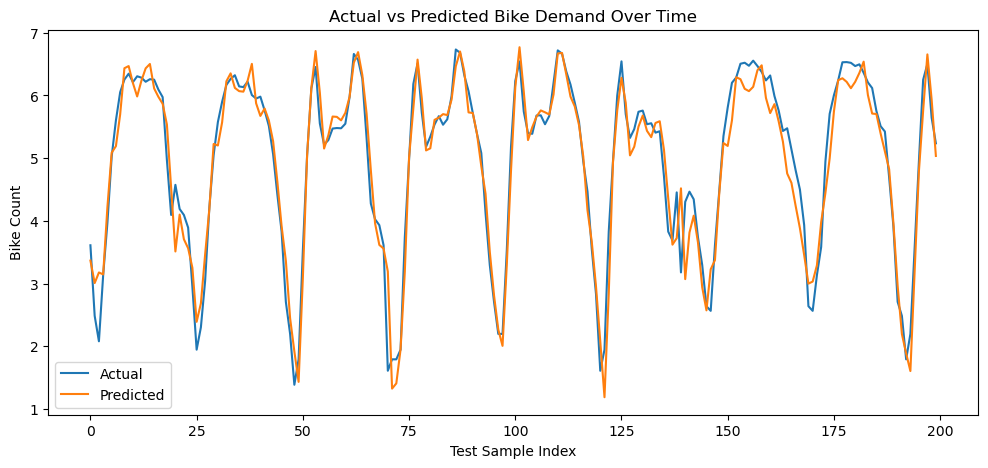

In [110]:
comparison_df.head(200).plot(figsize=(12, 5))

plt.title("Actual vs Predicted Bike Demand Over Time")
plt.xlabel("Test Sample Index")
plt.ylabel("Bike Count")
plt.show()

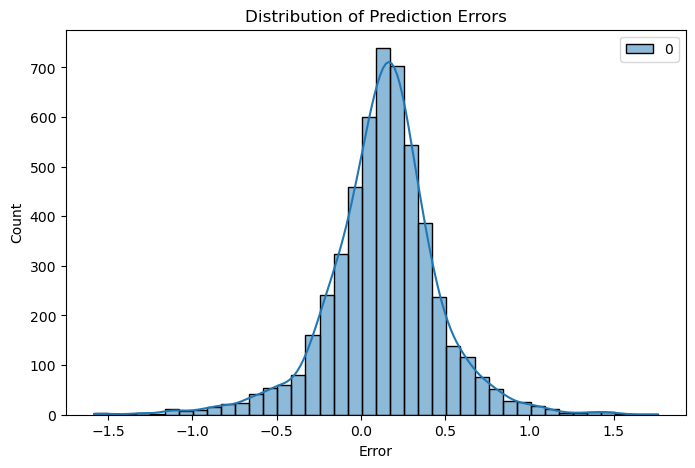

In [111]:
errors = y_test - y_pred

plt.figure(figsize=(8,5))
sns.histplot(errors, bins=40, kde=True)
plt.title("Distribution of Prediction Errors")
plt.xlabel("Error")
plt.show()

In [112]:
import joblib

joblib.dump(reg, "bike_share_model.pkl")
joblib.dump(x.columns.tolist(), "model_columns.pkl")

print("Model and columns saved successfully!")

Model and columns saved successfully!
